## Basics

In [1]:
!wget https://raw.githubusercontent.com/TTAyanlade/vlm/main/tips_ML_Phenotype.txt

--2026-05-03 19:04:36--  https://raw.githubusercontent.com/TTAyanlade/vlm/main/tips_ML_Phenotype.txt
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 36739 (36K) [text/plain]
Saving to: ‘tips_ML_Phenotype.txt’

tips_ML_Phenotype.t 100%[===================>]  35.88K  --.-KB/s    in 0s      

2026-05-03 19:04:37 (141 MB/s) - ‘tips_ML_Phenotype.txt’ saved [36739/36739]



In [2]:
with open('tips_ML_Phenotype.txt', 'r', encoding='utf-8') as f:
    text = f.read()

In [4]:
print("length of dataset in characters: ", len(text))

length of dataset in characters:  36358


In [5]:
print(text[:1000])

Phenotyping Data and ML
The enormous volume, variety, velocity, and veracity of imaging and remote-sensing data
generated by such real-time platforms represent a ‘big data’ problem. The data generated
by these near real-time platforms must be efﬁciently archived and retrieved for analysis. Although
the analysis and interpretation of such (image-based) big data are challenging, the ensuing
possibilities that can impact on agricultural production make it a promising approach for HTP
and HTSP. ML approaches present a scalable, modular strategy for data analysis, especially for
the new application domain of ‘plant stress analytics’. Recent studies on HTSP using images
obtained from UAV-based platforms to detect weeds in wheat (Triticum aestivum L.) [23], maize
[21], and sunﬂower (Helianthus annuus L.) [24] using ML algorithms have paved a new path for
better stress management practices on spatial and temporal basis.
ML is an inherently multidisciplinary approach to data analysis that draws

In [6]:
# here are all the unique characters that occur in this text
chars = sorted(list(set(text)))
vocab_size = len(chars)
print(''.join(chars))
print(vocab_size)


 %'(),-./0123456789:;?ABCDEFGHIKLMNOPQRSTUVWY[]abcdefghijklmnopqrstuvwxyzï–‘’ﬁﬂ
81


In [7]:
# create a mapping from characters to integers
stoi = { ch:i for i,ch in enumerate(chars) }
itos = { i:ch for i,ch in enumerate(chars) }
encode = lambda s: [stoi[c] for c in s] # encoder: take a string, output a list of integers
decode = lambda l: ''.join([itos[i] for i in l]) # decoder: take a list of integers, output a string

print(encode("plants are cool"))
print(decode(encode("plants are cool")))

[64, 60, 49, 62, 68, 67, 2, 49, 66, 53, 2, 51, 63, 63, 60]
plants are cool


Other tokenizers

https://huggingface.co/docs/transformers/main_classes/tokenizer

https://github.com/google/sentencepiece

In [8]:
# let's now encode the entire text dataset and store it into a torch.Tensor
import torch # we use PyTorch: https://pytorch.org
data = torch.tensor(encode(text), dtype=torch.long)
print(data.shape, data.dtype)
print(data[:1000]) # the 1000 characters we looked at earier will to the GPT look like this

torch.Size([36358]) torch.int64
tensor([38, 56, 53, 62, 63, 68, 73, 64, 57, 62, 55,  2, 27, 49, 68, 49,  2, 49,
        62, 52,  2, 35, 34,  0, 42, 56, 53,  2, 53, 62, 63, 66, 61, 63, 69, 67,
         2, 70, 63, 60, 69, 61, 53,  7,  2, 70, 49, 66, 57, 53, 68, 73,  7,  2,
        70, 53, 60, 63, 51, 57, 68, 73,  7,  2, 49, 62, 52,  2, 70, 53, 66, 49,
        51, 57, 68, 73,  2, 63, 54,  2, 57, 61, 49, 55, 57, 62, 55,  2, 49, 62,
        52,  2, 66, 53, 61, 63, 68, 53,  8, 67, 53, 62, 67, 57, 62, 55,  2, 52,
        49, 68, 49,  0, 55, 53, 62, 53, 66, 49, 68, 53, 52,  2, 50, 73,  2, 67,
        69, 51, 56,  2, 66, 53, 49, 60,  8, 68, 57, 61, 53,  2, 64, 60, 49, 68,
        54, 63, 66, 61, 67,  2, 66, 53, 64, 66, 53, 67, 53, 62, 68,  2, 49,  2,
        77, 50, 57, 55,  2, 52, 49, 68, 49, 78,  2, 64, 66, 63, 50, 60, 53, 61,
         9,  2, 42, 56, 53,  2, 52, 49, 68, 49,  2, 55, 53, 62, 53, 66, 49, 68,
        53, 52,  0, 50, 73,  2, 68, 56, 53, 67, 53,  2, 62, 53, 49, 66,  2, 66,
        

In [9]:
# Let's now split up the data into train and validation sets
n = int(0.9*len(data)) # first 90% will be train, rest val
train_data = data[:n]
val_data = data[n:]

In [10]:
block_size = 8
train_data[:block_size+1]

tensor([38, 56, 53, 62, 63, 68, 73, 64, 57])

In [11]:
x = train_data[:block_size]
y = train_data[1:block_size+1]
for t in range(block_size):
    context = x[:t+1]
    target = y[t]
    print(f"when input is {context} the target: {target}")

when input is tensor([38]) the target: 56
when input is tensor([38, 56]) the target: 53
when input is tensor([38, 56, 53]) the target: 62
when input is tensor([38, 56, 53, 62]) the target: 63
when input is tensor([38, 56, 53, 62, 63]) the target: 68
when input is tensor([38, 56, 53, 62, 63, 68]) the target: 73
when input is tensor([38, 56, 53, 62, 63, 68, 73]) the target: 64
when input is tensor([38, 56, 53, 62, 63, 68, 73, 64]) the target: 57


In [12]:
torch.manual_seed(1337)

batch_size = 4 # how many independent sequences will we process in parallel?
block_size = 8 # what is the maximum context length for predictions?

def get_batch(split):
    # generate a small batch of data of inputs x and targets y
    data = train_data if split == 'train' else val_data
    ix = torch.randint(len(data) - block_size, (batch_size,))
    x = torch.stack([data[i:i+block_size] for i in ix])
    y = torch.stack([data[i+1:i+block_size+1] for i in ix])
    return x, y

xb, yb = get_batch('train')
print('inputs:')
print(xb.shape)
print(xb)
print('targets:')
print(yb.shape)
print(yb)

print('----')

for b in range(batch_size): # batch dimension
    for t in range(block_size): # time dimension
        context = xb[b, :t+1]
        target = yb[b,t]
        print(f"when input is {context.tolist()} the target: {target}")

inputs:
torch.Size([4, 8])
tensor([[ 2, 68, 66, 53, 61, 53, 62, 52],
        [49, 60, 73, 67, 57, 67,  2, 68],
        [ 2, 69, 67, 69, 49, 60, 60, 73],
        [ 0, 68, 53, 51, 56, 62, 57, 65]])
targets:
torch.Size([4, 8])
tensor([[68, 66, 53, 61, 53, 62, 52, 63],
        [60, 73, 67, 57, 67,  2, 68, 56],
        [69, 67, 69, 49, 60, 60, 73,  2],
        [68, 53, 51, 56, 62, 57, 65, 69]])
----
when input is [2] the target: 68
when input is [2, 68] the target: 66
when input is [2, 68, 66] the target: 53
when input is [2, 68, 66, 53] the target: 61
when input is [2, 68, 66, 53, 61] the target: 53
when input is [2, 68, 66, 53, 61, 53] the target: 62
when input is [2, 68, 66, 53, 61, 53, 62] the target: 52
when input is [2, 68, 66, 53, 61, 53, 62, 52] the target: 63
when input is [49] the target: 60
when input is [49, 60] the target: 73
when input is [49, 60, 73] the target: 67
when input is [49, 60, 73, 67] the target: 57
when input is [49, 60, 73, 67, 57] the target: 67
when input is [4

In [12]:
print(xb) # our input to the transformer

tensor([[ 2, 68, 66, 53, 61, 53, 62, 52],
        [49, 60, 73, 67, 57, 67,  2, 68],
        [ 2, 69, 67, 69, 49, 60, 60, 73],
        [ 0, 68, 53, 51, 56, 62, 57, 65]])


# Full code

In [13]:
import torch
import torch.nn as nn
from torch.nn import functional as F

# hyperparameters
batch_size = 16 # how many independent sequences will we process in parallel?
block_size = 32 # what is the maximum context length for predictions?
max_iters = 5000
eval_interval = 100
learning_rate = 1e-3
device = 'cuda' if torch.cuda.is_available() else 'cpu'
eval_iters = 200
n_embd = 64
n_head = 4
n_layer = 4
dropout = 0.0
# ------------

torch.manual_seed(1337)

!wget https://raw.githubusercontent.com/TTAyanlade/vlm/main/tips_ML_Phenotype.txt
with open('tips_ML_Phenotype.txt', 'r', encoding='utf-8') as f:
    text = f.read()

--2026-05-03 19:05:00--  https://raw.githubusercontent.com/TTAyanlade/vlm/main/tips_ML_Phenotype.txt
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 36739 (36K) [text/plain]
Saving to: ‘tips_ML_Phenotype.txt.1’

tips_ML_Phenotype.t 100%[===================>]  35.88K  --.-KB/s    in 0s      

2026-05-03 19:05:00 (114 MB/s) - ‘tips_ML_Phenotype.txt.1’ saved [36739/36739]



Total tokens: 8623
Vocab size: 50257

Running experiment: gpt_rope_tiktoken_layer4_embd64
step 0: train loss 10.9725, val loss 11.0196
step 100: train loss 5.6104, val loss 6.8980
step 200: train loss 4.3541, val loss 6.5351
step 300: train loss 3.2599, val loss 6.4660
step 400: train loss 2.3786, val loss 6.8180
step 500: train loss 1.6824, val loss 7.0477
step 600: train loss 1.1765, val loss 7.4211
step 700: train loss 0.8100, val loss 7.7992
step 800: train loss 0.5737, val loss 8.1011
step 900: train loss 0.4433, val loss 8.3356
step 1000: train loss 0.3676, val loss 8.4548
step 1100: train loss 0.3223, val loss 8.6684
step 1200: train loss 0.2838, val loss 8.8871
step 1300: train loss 0.2560, val loss 8.9911
step 1400: train loss 0.2514, val loss 9.1137
step 1500: train loss 0.2340, val loss 9.1620
step 1600: train loss 0.2245, val loss 9.3513
step 1700: train loss 0.2171, val loss 9.4417
step 1800: train loss 0.2114, val loss 9.4658
step 1900: train loss 0.1985, val loss 9.5231


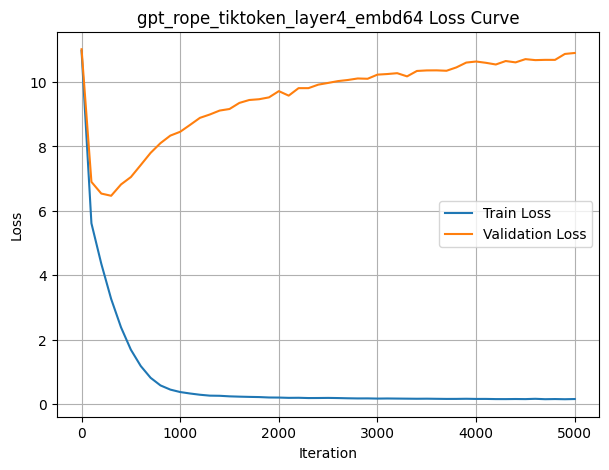

Saved model: /home/adumka/ISU_work/assignment/result/taskB/gpt_rope_tiktoken_layer4_embd64_model.pt
Saved plot: /home/adumka/ISU_work/assignment/result/taskB/gpt_rope_tiktoken_layer4_embd64_loss.png

Running experiment: gpt_rope_tiktoken_layer4_embd128
step 0: train loss 11.0231, val loss 11.0542
step 100: train loss 4.4182, val loss 6.5000
step 200: train loss 2.5147, val loss 6.5103
step 300: train loss 1.2324, val loss 6.9689
step 400: train loss 0.5451, val loss 7.3861
step 500: train loss 0.3158, val loss 7.5585
step 600: train loss 0.2540, val loss 7.8026
step 700: train loss 0.2274, val loss 7.9856
step 800: train loss 0.2075, val loss 8.0884
step 900: train loss 0.1967, val loss 8.1740
step 1000: train loss 0.1839, val loss 8.2601
step 1100: train loss 0.1775, val loss 8.3559
step 1200: train loss 0.1770, val loss 8.4456
step 1300: train loss 0.1719, val loss 8.4760
step 1400: train loss 0.1709, val loss 8.6154
step 1500: train loss 0.1659, val loss 8.5057
step 1600: train loss

In [ ]:
## changing the tokenization from character level to subword token using tiktoken ##

# # here are all the unique characters that occur in this text
# chars = sorted(list(set(text)))
# vocab_size = len(chars)
# # create a mapping from characters to integers
# stoi = { ch:i for i,ch in enumerate(chars) }
# itos = { i:ch for i,ch in enumerate(chars) }
# encode = lambda s: [stoi[c] for c in s] # encoder: take a string, output a list of integers
# decode = lambda l: ''.join([itos[i] for i in l]) # decoder: take a list of integers, output a string

# # Train and test splits
# data = torch.tensor(encode(text), dtype=torch.long)

import tiktoken

enc = tiktoken.get_encoding("gpt2")

def encode(s):
    return enc.encode(s)

def decode(tokens):
    return enc.decode(tokens)

data = torch.tensor(encode(text), dtype=torch.long)
vocab_size = enc.n_vocab

print("Total tokens:", len(data))
print("Vocab size:", vocab_size)

n = int(0.9*len(data)) # first 90% will be train, rest val
train_data = data[:n]
val_data = data[n:]

# data loading
def get_batch(split):
    # generate a small batch of data of inputs x and targets y
    data = train_data if split == 'train' else val_data
    ix = torch.randint(len(data) - block_size, (batch_size,))
    x = torch.stack([data[i:i+block_size] for i in ix])
    y = torch.stack([data[i+1:i+block_size+1] for i in ix])
    x, y = x.to(device), y.to(device)
    return x, y

@torch.no_grad()
def estimate_loss(model):
    out = {}

    model.eval()

    for split in ['train', 'val']:
        losses = torch.zeros(eval_iters)

        for k in range(eval_iters):
            X, Y = get_batch(split)
            logits, loss = model(X, Y)
            losses[k] = loss.item()

        out[split] = losses.mean().item()

    model.train()
    return out

def apply_rope(x):
    """
    x shape: (B, T, head_size)
    Applies rotary positional embedding to query/key.
    """
    B, T, C = x.shape

    assert C % 2 == 0, "RoPE requires head_size to be even."

    half = C // 2

    freq_seq = torch.arange(half, device=x.device, dtype=x.dtype)
    inv_freq = 1.0 / (10000 ** (freq_seq / half))

    positions = torch.arange(T, device=x.device, dtype=x.dtype)
    angles = torch.einsum("t,f->tf", positions, inv_freq)

    sin = torch.sin(angles).unsqueeze(0)
    cos = torch.cos(angles).unsqueeze(0)

    x1 = x[..., :half]
    x2 = x[..., half:]

    rotated = torch.cat(
        [x1 * cos - x2 * sin, x1 * sin + x2 * cos],
        dim=-1
    )

    return rotated


class Head(nn.Module):
    """ one head of self-attention """

    def __init__(self, head_size):
        super().__init__()
        self.key = nn.Linear(n_embd, head_size, bias=False)
        self.query = nn.Linear(n_embd, head_size, bias=False)
        self.value = nn.Linear(n_embd, head_size, bias=False)
        self.register_buffer('tril', torch.tril(torch.ones(block_size, block_size)))

        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        B,T,C = x.shape
        k = self.key(x)   # (B,T,C)
        q = self.query(x) # (B,T,C)

        k = apply_rope(k)
        q = apply_rope(q)

        # compute attention scores ("affinities")
        wei = q @ k.transpose(-2,-1) * C**-0.5 # (B, T, C) @ (B, C, T) -> (B, T, T)
        wei = wei.masked_fill(self.tril[:T, :T] == 0, float('-inf')) # (B, T, T)
        wei = F.softmax(wei, dim=-1) # (B, T, T)
        wei = self.dropout(wei)
        # perform the weighted aggregation of the values
        v = self.value(x) # (B,T,C)
        out = wei @ v # (B, T, T) @ (B, T, C) -> (B, T, C)
        return out

class MultiHeadAttention(nn.Module):
    """ multiple heads of self-attention in parallel """

    def __init__(self, num_heads, head_size):
        super().__init__()
        self.heads = nn.ModuleList([Head(head_size) for _ in range(num_heads)])
        self.proj = nn.Linear(n_embd, n_embd)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        out = torch.cat([h(x) for h in self.heads], dim=-1)
        out = self.dropout(self.proj(out))
        return out

class FeedFoward(nn.Module):
    """ a simple linear layer followed by a non-linearity """

    def __init__(self, n_embd):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_embd, 4 * n_embd),
            nn.ReLU(),
            nn.Linear(4 * n_embd, n_embd),
            nn.Dropout(dropout),
        )

    def forward(self, x):
        return self.net(x)

class Block(nn.Module):
    """ Transformer block: communication followed by computation """

    def __init__(self, n_embd, n_head):
        # n_embd: embedding dimension, n_head: the number of heads we'd like
        super().__init__()
        head_size = n_embd // n_head
        self.sa = MultiHeadAttention(n_head, head_size)
        self.ffwd = FeedFoward(n_embd)
        self.ln1 = nn.LayerNorm(n_embd)
        self.ln2 = nn.LayerNorm(n_embd)

    def forward(self, x):
        x = x + self.sa(self.ln1(x))
        x = x + self.ffwd(self.ln2(x))
        return x

#  simple  model
class LanguageModel(nn.Module):

    def __init__(self, vocab_size, n_embd, n_layer, n_head):
        super().__init__()
        # each token directly reads off the logits for the next token from a lookup table
        self.token_embedding_table = nn.Embedding(vocab_size, n_embd)
        # self.position_embedding_table = nn.Embedding(block_size, n_embd)
        self.blocks = nn.Sequential(*[Block(n_embd, n_head=n_head) for _ in range(n_layer)])
        self.ln_f = nn.LayerNorm(n_embd) # final layer norm
        self.lm_head = nn.Linear(n_embd, vocab_size)

    def forward(self, idx, targets=None):
        B, T = idx.shape

        # idx and targets are both (B,T) tensor of integers
        # tok_emb = self.token_embedding_table(idx) # (B,T,C)
        # pos_emb = self.position_embedding_table(torch.arange(T, device=device)) # (T,C)
        # x = tok_emb + pos_emb # (B,T,C)

        x = self.token_embedding_table(idx)

        x = self.blocks(x) # (B,T,C)
        x = self.ln_f(x) # (B,T,C)
        logits = self.lm_head(x) # (B,T,vocab_size)

        if targets is None:
            loss = None
        else:
            B, T, C = logits.shape
            logits = logits.view(B*T, C)
            targets = targets.view(B*T)
            loss = F.cross_entropy(logits, targets)

        return logits, loss

    def generate(self, idx, max_new_tokens):
        # idx is (B, T) array of indices in the current context
        for _ in range(max_new_tokens):
            # crop idx to the last block_size tokens
            idx_cond = idx[:, -block_size:]
            # get the predictions
            logits, loss = self(idx_cond)
            # focus only on the last time step
            logits = logits[:, -1, :] # becomes (B, C)
            # apply softmax to get probabilities
            probs = F.softmax(logits, dim=-1) # (B, C)
            # sample from the distribution
            idx_next = torch.multinomial(probs, num_samples=1) # (B, 1)
            # append sampled index to the running sequence
            idx = torch.cat((idx, idx_next), dim=1) # (B, T+1)
        return idx

# model = LanguageModel()
# m = model.to(device)
# # print the number of parameters in the model
# print(sum(p.numel() for p in m.parameters())/1e6, 'M parameters')

# # create a PyTorch optimizer
# optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate)

# import time

# start_time = time.time()

# for iter in range(max_iters):

#     # every once in a while evaluate the loss on train and val sets
#     if iter % eval_interval == 0 or iter == max_iters - 1:
#         losses = estimate_loss()
#         print(f"step {iter}: train loss {losses['train']:.4f}, val loss {losses['val']:.4f}")

#     # sample a batch of data
#     xb, yb = get_batch('train')

#     # evaluate the loss
#     logits, loss = model(xb, yb)
#     optimizer.zero_grad(set_to_none=True)
#     loss.backward()
#     optimizer.step()

# end_time = time.time()
# elapsed_time = end_time - start_time
# print(f"Total time taken: {elapsed_time} seconds")



import pandas as pd
import os
import matplotlib.pyplot as plt

output_dir = "/home/adumka/ISU_work/assignment/result/taskB"
os.makedirs(output_dir, exist_ok=True)

n_layer_list = [4, 6, 8]
n_embd_list = [64, 128, 256]

experiment_results = []

for n_layer in n_layer_list:
    for n_embd in n_embd_list:

        exp_name = f"gpt_rope_tiktoken_layer{n_layer}_embd{n_embd}"

        print("\n" + "=" * 80)
        print(f"Running experiment: {exp_name}")
        print("=" * 80)

        model = LanguageModel(
            vocab_size=vocab_size,
            n_embd=n_embd,
            n_layer=n_layer,
            n_head=n_head
        ).to(device)

        optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate)

        train_losses = []
        val_losses = []
        steps = []

        for iter in range(max_iters + 1):

            if iter % eval_interval == 0:
                losses = estimate_loss(model)

                print(
                    f"step {iter}: "
                    f"train loss {losses['train']:.4f}, "
                    f"val loss {losses['val']:.4f}"
                )

                steps.append(iter)
                train_losses.append(losses["train"])
                val_losses.append(losses["val"])

            xb, yb = get_batch("train")

            logits, loss = model(xb, yb)
            optimizer.zero_grad(set_to_none=True)
            loss.backward()
            optimizer.step()

        final_train_loss = train_losses[-1]
        final_val_loss = val_losses[-1]

        model_path = os.path.join(output_dir, f"{exp_name}_model.pt")
        torch.save(model.state_dict(), model_path)

        plot_path = os.path.join(output_dir, f"{exp_name}_loss.png")

        plt.figure(figsize=(7, 5))
        plt.plot(steps, train_losses, label="Train Loss")
        plt.plot(steps, val_losses, label="Validation Loss")
        plt.xlabel("Iteration")
        plt.ylabel("Loss")
        plt.title(f"{exp_name} Loss Curve")
        plt.legend()
        plt.grid(True)
        plt.savefig(plot_path, dpi=300, bbox_inches="tight")
        plt.show()

        experiment_results.append({
            "experiment": exp_name,
            "n_layer": n_layer,
            "n_embd": n_embd,
            "n_head": n_head,
            "block_size": block_size,
            "batch_size": batch_size,
            "learning_rate": learning_rate,
            "final_train_loss": final_train_loss,
            "final_val_loss": final_val_loss,
            "model_path": model_path,
            "plot_path": plot_path
        })

        print("Saved model:", model_path)
        print("Saved plot:", plot_path)

        del model
        torch.cuda.empty_cache()


results_df = pd.DataFrame(experiment_results)

csv_path = os.path.join(output_dir, "taskB_hyperparameter_results.csv")
results_df.to_csv(csv_path, index=False)

display(results_df)

print("Saved results to:", csv_path)

In [ ]:
# import torch.nn.functional as F

# class MultiHeadAttention(nn.Module):
#     """ Fused Flash Attention implementation """

#     def __init__(self, n_head, n_embd, dropout, block_size):
#         super().__init__()
#         assert n_embd % n_head == 0
#         # Key, Query, Value projections for all heads at once
#         self.c_attn = nn.Linear(n_embd, 3 * n_embd, bias=False)
#         # Output projection
#         self.c_proj = nn.Linear(n_embd, n_embd)
#         # Regularization
#         self.dropout = dropout
#         self.n_head = n_head
#         self.n_embd = n_embd
#         # Flash Attention handles the causal mask internally if is_causal=True

#     def forward(self, x):
#         B, T, C = x.shape # batch size, sequence length, embedding dimensionality (n_embd)

#         # Calculate query, key, values for all heads in batch
#         # q, k, v shape: (B, T, n_head, head_size)
#         q, k, v = self.c_attn(x).split(self.n_embd, dim=2)

#         hs = C // self.n_head
#         q = q.view(B, T, self.n_head, hs).transpose(1, 2) # (B, nh, T, hs)
#         k = k.view(B, T, self.n_head, hs).transpose(1, 2) # (B, nh, T, hs)
#         v = v.view(B, T, self.n_head, hs).transpose(1, 2) # (B, nh, T, hs)

#         # ---- FLASH ATTENTION CORE ----
#         # This replaces the entire manual Head logic
#         out = F.scaled_dot_product_attention(
#             q, k, v,
#             attn_mask=None,
#             dropout_p=self.dropout if self.training else 0,
#             is_causal=True # This handles the 'tril' masking automatically!
#         )
#         # ------------------------------

#         out = out.transpose(1, 2).contiguous().view(B, T, C) # re-assemble heads
#         out = self.c_proj(out)
#         return out

In [ ]:
# generate text
context = torch.zeros((1, 1), dtype=torch.long, device=device)



In [ ]:
print(context)

tensor([[0]])


In [ ]:
print(decode(m.generate(context, max_new_tokens=2000)[0].tolist()))


ML methods can also be
volume deployment these prediction reduction of Stress visuances comparinotive bliew, such images reluectral munxar, and thisholdentispects
citrus) bredicting
stress very lepeciall
neural network (GRNNNs) and AV, and prediction shek model does not lispecially this can use theticultuolantize, structures and
supervised’. learns the inducced [27]. In many level new experg, moslerant of information’.

The next leaf striess to make model that different speence our umpraptione ch0
identiﬁcation, (i) This chegorithms, expenderated prov-hled. The is can experconsiple
caill
turnix sumples or possibilities rand new discripponent henerarchy
of wre ML methods probleders.
PIt. Gis model. This is clustering
and HLB-therd hnave
model data trien roussinnes mixture opentially these onew analso crreph problem. In another examples using spectrophotometerial imagrie dataset’, put neurposts thatforks, degection of choices or tremcinarly
prominence. For exarly radit next, fachekal 